
# Spotify Data Analysis with Python

## Project Objective
The goal of this project is to perform Exploratory Data Analysis (EDA) on Spotify music data to understand patterns in song characteristics and their relationship with popularity.

We analyze features such as danceability, energy, tempo, acousticness, loudness, and valence to uncover music trends and factors that influence song success.


In [25]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)



## Load the Dataset
tracks.csv → Song metadata  
artists.csv → Artist information


In [26]:
import os
base_path = r"D:\Data Analytics\Projects\Spotify Data Analysis\spotify_data"
tracks = pd.read_csv(os.path.join(base_path, "tracks.csv"))
artists = pd.read_csv(os.path.join(base_path, "artists.csv"))

print("Tracks Dataset Shape:", tracks.shape)
print("Artists Dataset Shape:", artists.shape)

Tracks Dataset Shape: (586672, 20)
Artists Dataset Shape: (1104349, 5)


In [27]:
tracks.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [28]:
artists.head()

,id,followers,genres,name,popularity
0,0DheY5irMjBUeLybbCUEZ2,0.0,[],Armid & Amir Zare Pashai feat. Sara Rouzbehani,0
1,0DlhY15l3wsrnlfGio2bjU,5.0,[],ปูนา ภาวิณี,0
2,0DmRESX2JknGPQyO15yxg7,0.0,[],Sadaa,0
3,0DmhnbHjm1qw6NCYPeZNgJ,0.0,[],Tra'gruda,0
4,0Dn11fWM7vHQ3rinvWEl4E,2.0,[],Ioannis Panoutsopoulos,0


## Understanding the Dataset

In [29]:
tracks.info()

<class 'pandas.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  str    
 1   name              586601 non-null  str    
 2   popularity        586672 non-null  int64  
 3   duration_ms       586672 non-null  int64  
 4   explicit          586672 non-null  int64  
 5   artists           586672 non-null  str    
 6   id_artists        586672 non-null  str    
 7   release_date      586672 non-null  str    
 8   danceability      586672 non-null  float64
 9   energy            586672 non-null  float64
 10  key               586672 non-null  int64  
 11  loudness          586672 non-null  float64
 12  mode              586672 non-null  int64  
 13  speechiness       586672 non-null  float64
 14  acousticness      586672 non-null  float64
 15  instrumentalness  586672 non-null  float64
 16  liveness          586672 non-nu

In [30]:
tracks.describe()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,586672.000000,5.866720e+05,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000
mean,27.570053,2.300512e+05,0.044086,0.563594,0.542036,5.221603,-10.206067,0.658797,0.104864,0.449863,0.113451,0.213935,0.552292,118.464857,3.873382
std,18.370642,1.265261e+05,0.205286,0.166103,0.251923,3.519423,5.089328,0.474114,0.179893,0.348837,0.266868,0.184326,0.257671,29.764108,0.473162
min,0.000000,3.344000e+03,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,1.750930e+05,0.000000,0.453000,0.343000,2.000000,-12.891000,0.000000,0.034000,0.096900,0.000000,0.098300,0.346000,95.600000,4.000000
50%,27.000000,2.148930e+05,0.000000,0.577000,0.549000,5.000000,-9.243000,1.000000,0.044300,0.422000,0.000024,0.139000,0.564000,117.384000,4.000000
75%,41.000000,2.638670e+05,0.000000,0.686000,0.748000,8.000000,-6.482000,1.000000,0.076300,0.785000,0.009550,0.278000,0.769000,136.321000,4.000000
max,100.000000,5.621218e+06,1.000000,0.991000,1.000000,11.000000,5.376000,1.000000,0.971000,0.996000,1.000000,1.000000,1.000000,246.381000,5.000000


In [31]:
tracks.isnull().sum()

id                   0
name                71
popularity           0
duration_ms          0
explicit             0
artists              0
id_artists           0
release_date         0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
time_signature       0
dtype: int64

## Data Cleaning

In [32]:

tracks.drop_duplicates(inplace=True)
artists.drop_duplicates(inplace=True)


In [33]:
tracks = tracks.dropna()

In [34]:

tracks["release_date"] = pd.to_datetime(tracks["release_date"], errors="coerce")


## Feature Engineering

In [35]:

tracks["year"] = tracks["release_date"].dt.year
tracks["duration_sec"] = tracks["duration_ms"] / 1000


In [36]:

tracks["popularity_level"] = pd.cut(
    tracks["popularity"],
    bins=[0,30,60,100],
    labels=["Low","Medium","High"]
)


## Top Songs by Popularity

In [37]:

tracks.sort_values("popularity", ascending=False)[["name","artists","popularity"]].head(10)


,name,artists,popularity
93802,Peaches (feat. Daniel Caesar & Giveon),"['Justin Bieber', 'Daniel Caesar', 'Giveon']",100
93803,drivers license,['Olivia Rodrigo'],99
93804,Astronaut In The Ocean,['Masked Wolf'],98
92810,Save Your Tears,['The Weeknd'],97
92811,telepatía,['Kali Uchis'],97
93805,Leave The Door Open,"['Bruno Mars', 'Anderson .Paak', 'Silk Sonic']",96
92813,Blinding Lights,['The Weeknd'],96
92814,The Business,['Tiësto'],95
92819,Bandido,"['Myke Towers', 'Juhn']",94
91866,Streets,['Doja Cat'],94


## Feature Distributions

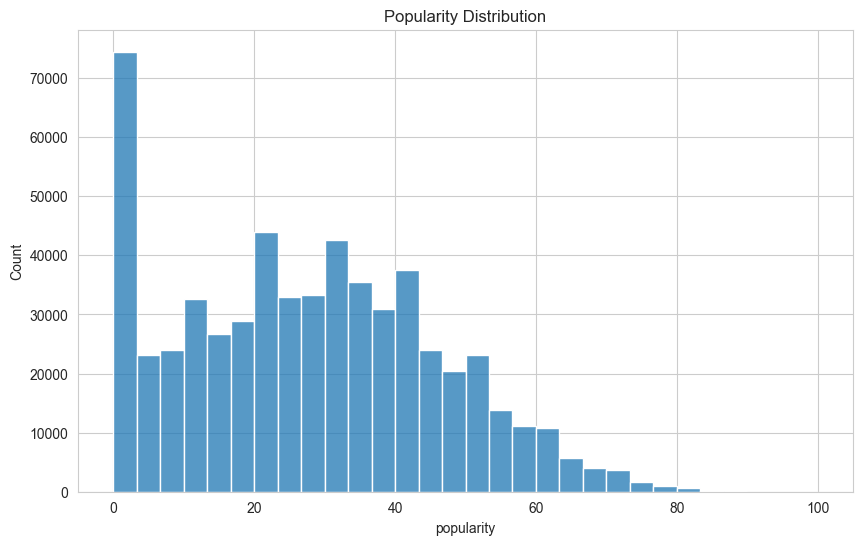

In [38]:

sns.histplot(tracks["popularity"], bins=30)
plt.title("Popularity Distribution")
plt.show()


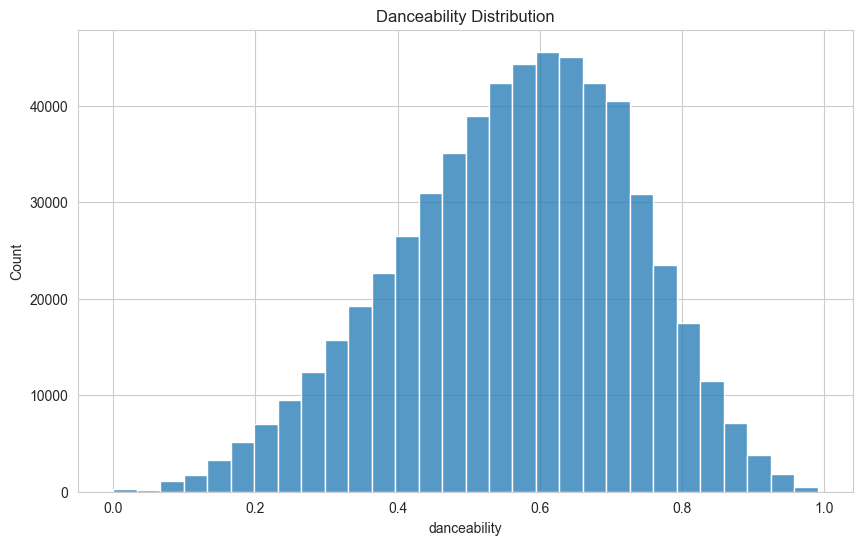

In [39]:

sns.histplot(tracks["danceability"], bins=30)
plt.title("Danceability Distribution")
plt.show()


## Correlation Analysis
This helps identify relationships between different song attributes.

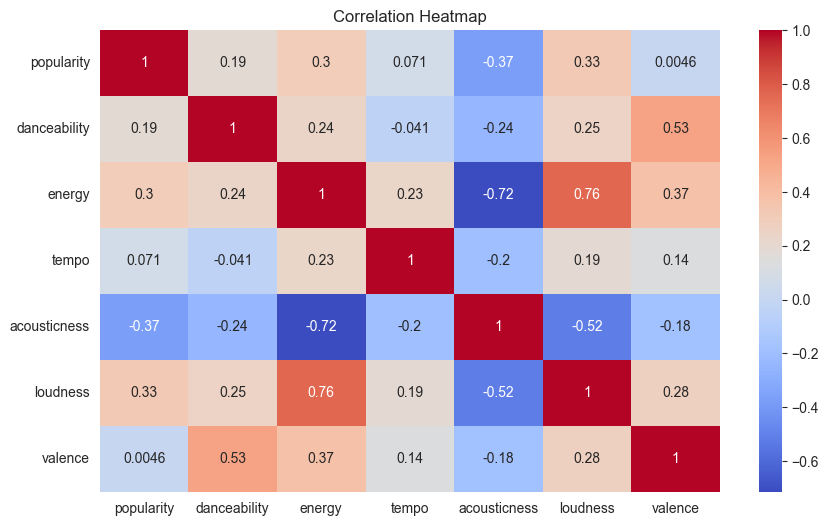

In [40]:

corr = tracks[['popularity','danceability','energy','tempo','acousticness','loudness','valence']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## Feature Relationships Analysis

In [60]:
sample_sp=tracks.sample(int(0.004*len(tracks)))
print(len(sample_sp))

2346


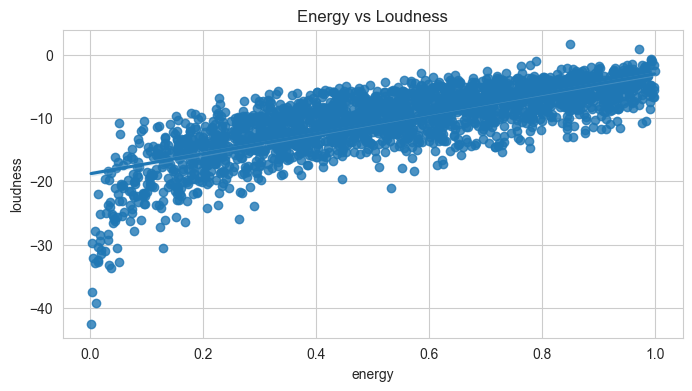

In [61]:
plt.figure(figsize=(8,4))
sns.regplot(data=sample_sp, y='loudness', x='energy')
plt.title("Energy vs Loudness")
plt.show()


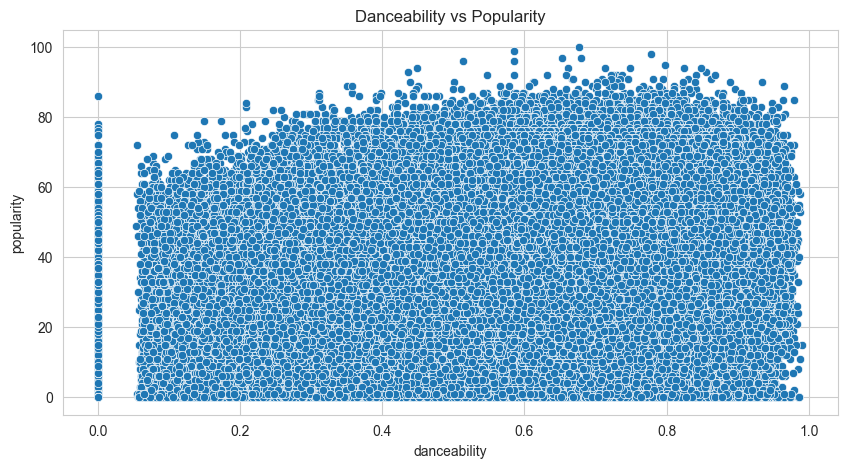

In [62]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="danceability", y="popularity", data=tracks)
plt.title("Danceability vs Popularity")
plt.show()


## Music Trends Over Time

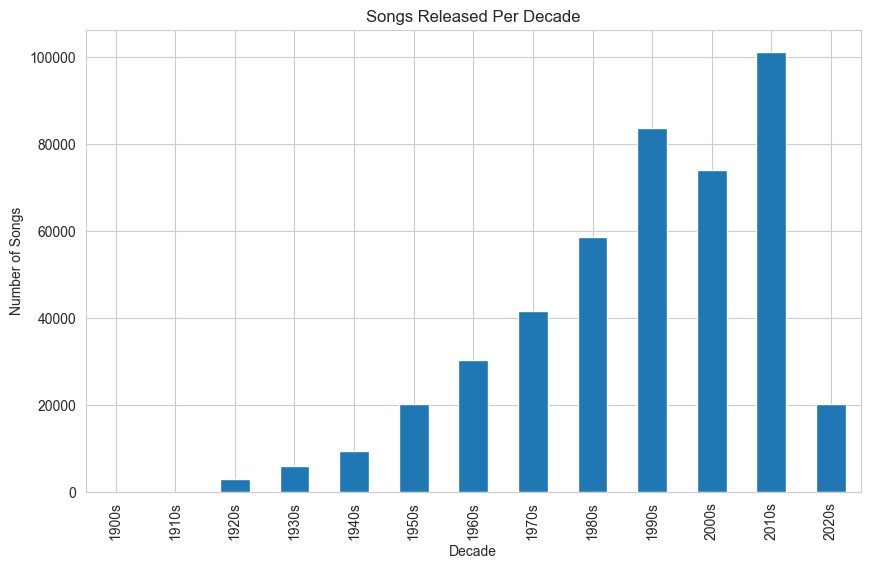

In [48]:
bins = list(range(int(tracks['year'].min()//10*10), int(tracks['year'].max()) + 10, 10))
labels = [f"{b}s" for b in bins[:-1]]
tracks['year_group'] = pd.cut(tracks['year'], bins=bins, labels=labels, right=False)

songs_per_group = tracks['year_group'].value_counts().sort_index()
songs_per_group.plot(kind='bar')
plt.title("Songs Released Per Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Songs")
plt.show()


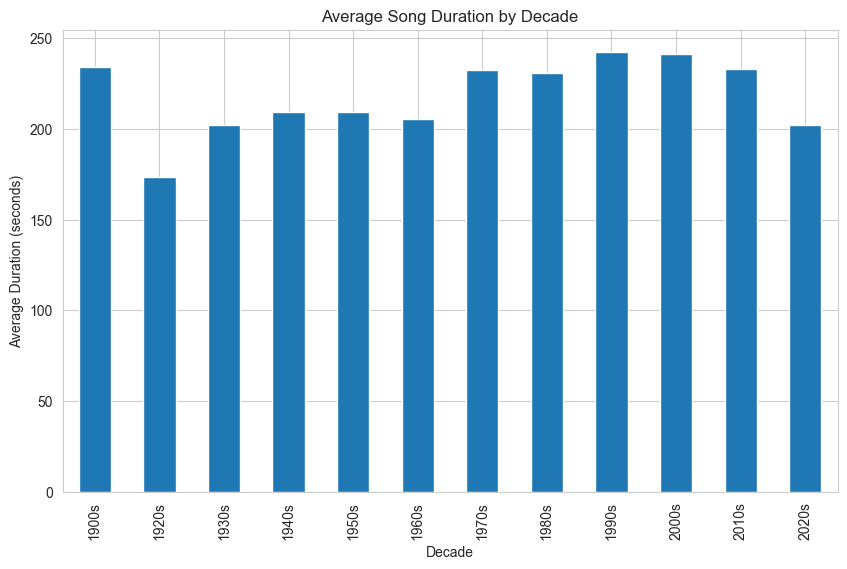

In [50]:
duration_group = tracks.groupby('year_group')['duration_sec'].mean()
duration_group.plot(kind='bar')
plt.title("Average Song Duration by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Duration (seconds)")
plt.show()

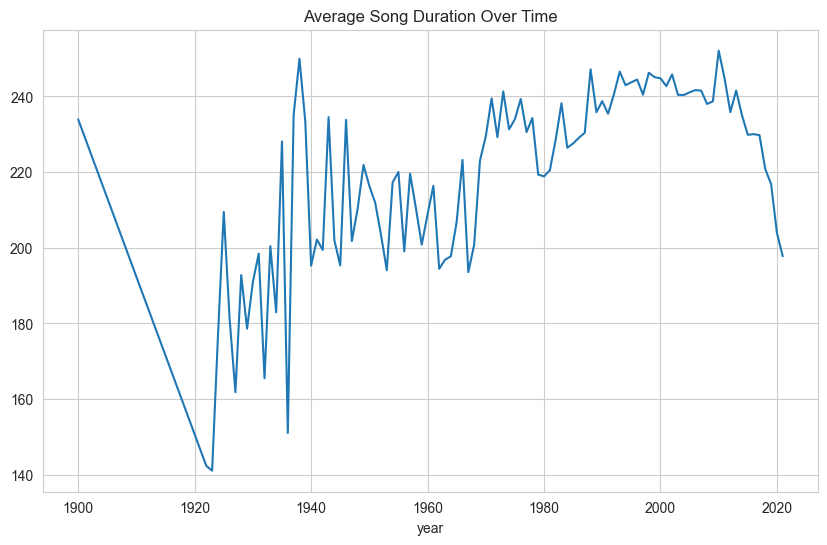

In [43]:

duration_trend = tracks.groupby("year")["duration_sec"].mean()
duration_trend.plot()
plt.title("Average Song Duration Over Time")
plt.show()


## Artist Analysis

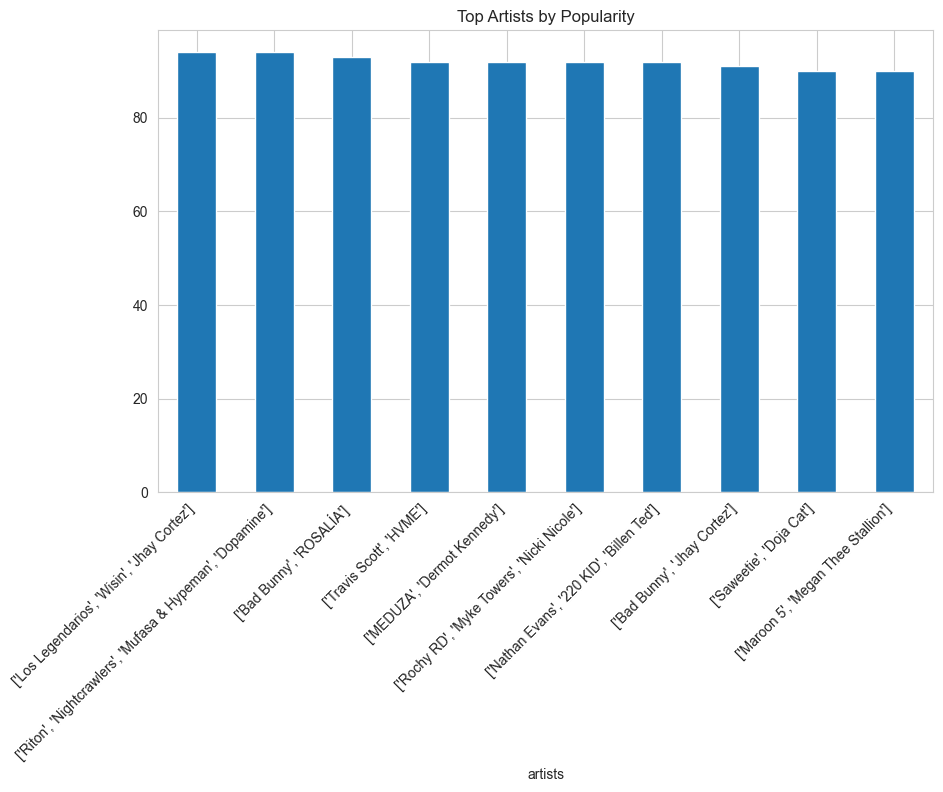

In [67]:
top_artists = tracks.groupby("artists")["popularity"].mean().sort_values(ascending=False).head(10)
top_artists.plot(kind="bar")
plt.title("Top Artists by Popularity")
plt.xticks(rotation=45, ha='right')   # rotate labels for readability
plt.show()


## Advanced Visualization

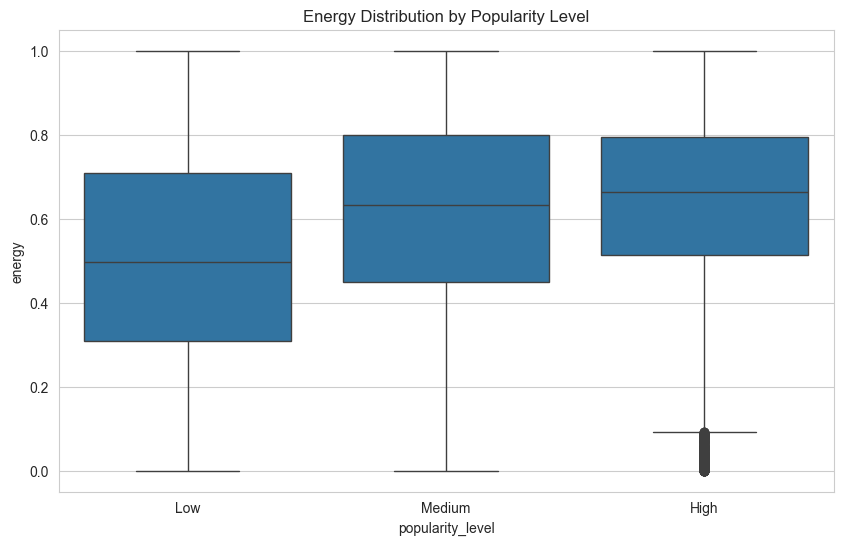

In [45]:
sns.boxplot(x="popularity_level", y="energy", data=tracks)
plt.title("Energy Distribution by Popularity Level")
plt.show()

## Playlist Recommendation Idea (New Insight)

Songs can be categorized into playlists based on their attributes:

• High danceability → Party playlist  
• High acousticness → Chill playlist  
• High energy → Workout playlist

In [46]:
tracks[tracks["danceability"] > 0.8][["name","artists","danceability"]].head()

,name,artists,danceability
72,Capítulo 2.14 - Banquero Anarquista,['Fernando Pessoa'],0.827
150,Weather Bird,"['Louis Armstrong', 'Earl Hines']",0.831
215,I Must Have That Man,['Lillie Delk Christian'],0.851
231,T.N.T.,['Fletcher Henderson & His Orchestra'],0.809
527,Sleepy Time Gal,['Harry Curtis'],0.825


## Key Insights

1. Songs with higher energy levels usually have higher loudness.
2. Danceable songs tend to be more popular.
3. Highly acoustic songs generally have lower popularity.
4. Song duration has slightly decreased over the years.
5. Certain artists consistently produce high popularity songs.

## Business Recommendations

• Music producers should focus on creating high-energy and danceable songs.

• Streaming platforms can recommend songs based on tempo and mood features.

• Artists should aim for shorter songs (around 3–4 minutes) to increase streaming frequency.

## Conclusion

This project analyzed Spotify music data to uncover patterns in song attributes and popularity. 
Exploratory Data Analysis helped identify relationships between features like energy, danceability, and popularity.

These insights can help music producers, streaming platforms, and artists better understand listener preferences and music trends.